# Phase 3: Game feel

**Skills:** turning a simulation into something you can play, without breaking determinism or replay.

Phase 3 puts a game on top of the sim and the agents:

- **A live session** (`server/session.py`) runs the sim, the keystone agent and the Narrator, the scenario clock, a budget and the player's tools. Agents think on a snapshot, off the sim thread, so the sim never waits for them.
- **God tools as typed intents.** Bacteria, fungi, mycorrhiza, compost, seed, water, excavate and mow are `inoculate`, `amend`, `seed`, `irrigate`, `excavate` and `disturb` intents. They go through the same validator as the agent's actions, and every gram they move is booked in the ledger.
- **A whisper** to the keystone agent: a human-in-the-loop suggestion it sees once, weighs, and may refuse.
- **Research and game modes.** Game mode has a budget and a **Scenario Director** that paces the story with validated events. Research mode has no director, free tools and a research-only `spill`.
- **Brownfield remediation,** the first scenario, and **scripted players** to balance it.
- **A FastAPI/WebSocket server** streaming ~10 frames/s, and a **PixiJS client** with a surface view, an underground view with the glowing hyphal network, a HUD and an inspector (observation → intent → rationale).

**Gate B:** 60 fps rendering with about 2,000 entities, and the brownfield scenario is playable end to end.

This notebook drives the headless half: the session, the scenario, the director, the whisper, the WebSocket protocol and replay. The client needs a browser, so it isn't run here. Agents use the **scripted** policy, so no model is called. It runs in about two minutes.

In [1]:
import os, sys, json, base64, time
from pathlib import Path
if Path.cwd().name == "notebooks":
    os.chdir("..")
sys.path.insert(0, str(Path.cwd()))

import matplotlib.pyplot as plt
import numpy as np
from fastapi.testclient import TestClient

from cognition import scripted
from cognition.llm import Router, routes_from_spec
from server import players
from server.app import ServerConfig, create_app
from server.scenarios import Brownfield
from server.session import FIELD_SCALES, TOOLS, GameSession
from sim import TICKS_PER_DAY
from sim.engine import describe
from sim.replay import replay

%matplotlib inline

## 1. The brownfield

An old industrial pad (32×32 m, the middle 16 of the 64 patches) has been stripped to subsoil and soaked in diesel-range hydrocarbons. The scenario is just **params plus setup intents**: four excavations and four spills from a `scenario` agent at tick 0. They go into the replay record like anything else, so the scenario itself replays.

In [2]:
g = GameSession(seed=1, agents=False)
for i in g.scenario.setup_intents():
    print(f"{i.kind:>8}  {describe(i)}")
g.advance(TICKS_PER_DAY)
print()
for o in g.status["objectives"]:
    print(f"{o['label']:>38}: now {o['value']:.2f}, target {o['target']:g}")
print(f"\nbudget {g.budget:g} | grant {g.scenario.grant:g} every {g.scenario.grant_every_days} days "
      f"| deadline day {g.scenario.deadline_days}")

excavate  excavate 90% of soil in x16-32 y16-32
excavate  excavate 90% of soil in x32-48 y16-32
excavate  excavate 90% of soil in x16-32 y32-48
excavate  excavate 90% of soil in x32-48 y32-48
   spill  spill 3500 g at (24,25)
   spill  spill 2500 g at (38,22)
   spill  spill 4000 g at (30,39)
   spill  spill 2000 g at (41,41)



              Contaminant left on site: now 1.00, target 0.25
                   Plant cover on site: now 0.14, target 0.6
    Site patches on the fungal network: now 0.00, target 10

budget 150 | grant 30 every 30 days | deadline day 1095


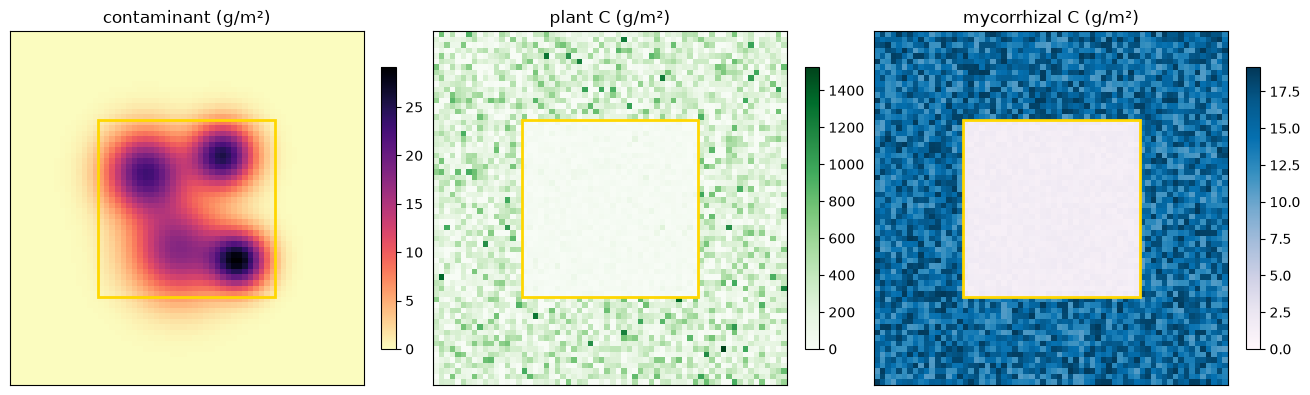

In [3]:
def field_map(ax, values, title, cmap, vmax=None):
    im = ax.imshow(values, cmap=cmap, vmin=0, vmax=vmax)
    x0, y0, x1, y1 = Brownfield().site
    ax.add_patch(plt.Rectangle((x0 - 0.5, y0 - 0.5), x1 - x0, y1 - y0, fill=False, ec="gold", lw=2))
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, shrink=0.75)

s = g.sim.state
fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
field_map(axes[0], s.contaminant, "contaminant (g/m²)", "magma_r")
field_map(axes[1], s.plant.c, "plant C (g/m²)", "Greens")
field_map(axes[2], s.mycorrhiza.c, "mycorrhizal C (g/m²)", "PuBu")

The three objectives are deliberately ordered. Bacteria and compost drive the cleanup; plants struggle on contaminated ground; and mycorrhizal fungi only establish where the soil is clean. So the network objective can't move until the contaminant one has.

## 2. Tools, budget and modes

`use_tool` checks, in order, that the tool exists, the mode allows it, the game isn't over, the player can afford it, and the validator accepts the intent. Only then does anything reach the sim. The first failure goes back to the player as the reason.

In [4]:
for name, t in TOOLS.items():
    print(f"{name:>20}  {t.cost:>3g}  {t.hint}" + ("  [research only]" if t.research_only else ""))
print()
print("compost on the site:", g.use_tool("compost", 30, 30))
print("water off the map:  ", g.use_tool("irrigate", 99, 10))
print("spill in game mode: ", g.use_tool("spill", 10, 10))
g.budget = 20
print("excavate on 20:     ", g.use_tool("excavate", 30, 30))
g.set_mode("research")
print("spill in research:  ", g.use_tool("spill", 10, 10))
print("excavate in research:", g.use_tool("excavate", 30, 30), "| unranked:", g.research_used)

  inoculate_bacteria   15  Cultured degraders: they eat the contaminant
     inoculate_fungi   15  White-rot fungi: tough, and degrade it too
inoculate_mycorrhiza   15  Seed the network where it can't reach
             compost   10  Feeds decomposers; nitrogen for plants
                seed    8  Sow a meadow mix
            irrigate    3  30 mm of water
            excavate   60  Dig out and haul away 60% of an 8x8 m block
                 mow    1  Cut plants to litter
               spill    0  Research only: contaminate a spot  [research only]

compost on the site: {'ok': True, 'cost': 10, 'budget': 140.0}
water off the map:   {'ok': False, 'error': 'geometry: irrigate centre out of bounds for 64x64 grid'}
spill in game mode:  {'ok': False, 'error': 'Spill is only available in research mode'}
excavate on 20:      {'ok': False, 'error': 'Excavate costs 60; budget is 20'}
spill in research:   {'ok': True, 'cost': 0.0, 'budget': 20.0}
excavate in research: {'ok': True, 'cost': 0.0, 

Switching to research mode marks the run as unranked for good, even if you switch back: research mode is for experiments, and its free tools would make the scenario meaningless.

## 3. Playing it: a greedy gardener against an idle one

`server/players.py` has two scripted players. `idle` never acts. `greedy` acts every two weeks and spends what it can on whichever objective is furthest behind: bacteria and compost on the worst contamination, mycorrhiza and seed on the thinnest network over clean ground, seed on the barest patch. If greedy can't win, the scenario is too hard; if idle wins, it's too easy.

The full three-year game takes about three minutes, so the CI gate runs it (`test_brownfield_is_winnable_by_a_sensible_player`, marked slow) and this notebook plays the first 180 days. The greedy session runs with the scripted keystone agent and Narrator, as the server does. Halfway through, the player whispers to the network (section 5).

In [5]:
DAYS, WHISPER_DAY = 180, 150

def play(session, player, days=DAYS, whisper_day=None, every=14):
    rows = []
    for day in range(days):
        if day % every == 0:
            player(session)
        if day == whisper_day:
            session.whisper(whisper_text(session))
        session.advance(TICKS_PER_DAY)
        rows.append([o["progress"] for o in session.status["objectives"]] + [session.budget])
    return np.array(rows)

def whisper_text(session):
    # Name the patch the network itself last saw as hungriest, plus one on the bare site.
    obs = session.mycelium.traces[-1]["observation"]
    hungry = obs["needy_partners"][0]["patch"] if obs["needy_partners"] else "r0c0"
    return f"please feed {hungry}, and r3c3 too"

t0 = time.perf_counter()
greedy = GameSession(seed=42)
g_rows = play(greedy, players.greedy, whisper_day=WHISPER_DAY)
idle = GameSession(seed=42, agents=False)
i_rows = play(idle, players.idle)
print(f"played {DAYS} days twice in {time.perf_counter() - t0:.0f} s")
for name, sess in (("greedy", greedy), ("idle", idle)):
    used = [i for i in sess.sim.accepted if i.agent == "user"]
    print(f"{name:>6}: {len(used)} tools used | progress {sess.status['progress']:.2f} | "
          + ", ".join(f"{o['key']} {o['value']:.2f}" for o in sess.status["objectives"]))

played 180 days twice in 78 s
greedy: 27 tools used | progress 0.49 | contaminant_left 0.86, site_cover 0.45, network_patches 6.00
  idle: 0 tools used | progress 0.42 | contaminant_left 0.95, site_cover 0.40, network_patches 6.00


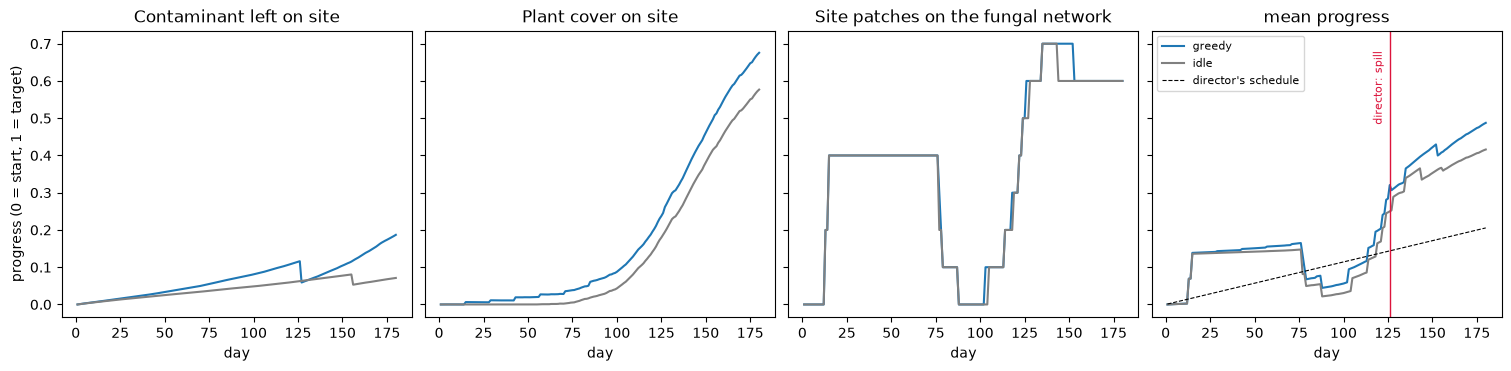

In [6]:
labels = [o.label for o in Brownfield().objectives]
days = np.arange(1, DAYS + 1)
schedule = days / (0.8 * Brownfield().deadline_days)  # the director's idea of "on time"
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6), constrained_layout=True, sharey=True)
for k, ax in enumerate(axes[:3]):
    ax.plot(days, g_rows[:, k], label="greedy")
    ax.plot(days, i_rows[:, k], label="idle", c="grey")
    ax.set(title=labels[k], xlabel="day")
axes[0].set_ylabel("progress (0 = start, 1 = target)")
ax = axes[3]
ax.plot(days, g_rows[:, :3].mean(1), label="greedy")
ax.plot(days, i_rows[:, :3].mean(1), c="grey", label="idle")
ax.plot(days, schedule, ls="--", c="k", lw=0.8, label="director's schedule")
for e in greedy.director.log:
    ax.axvline(e["day"], c="crimson", lw=1)
    ax.text(e["day"] - 3, 0.68, f"director: {e['kind']}", color="crimson", rotation=90, va="top", ha="right", fontsize=8)
ax.set(title="mean progress", xlabel="day"); ax.legend(loc="upper left", fontsize=8);

Six months in, greedy is ahead, but less than you might expect. The bare site greens up a little on its own as plants spread in from the meadow, and fungi creep in from the meadow to the site's corners without help, so idle gets credit for those too. The network objective flickers because those corner patches sit right at the 2 g C/m² threshold for counting as "on the network", and slip below it in late winter. Contaminant is where the player matters. Bacteria and compost are what move it: after six months greedy has removed 14% of it, idle 5%. The step down in each player's contaminant curve is a director spill (section 4).

The red line is the director. Greedy got ahead of the schedule, so a buried drum gave way on the site. Over three years this is what the CI gate checks: greedy wins on day 1024 of 1095, and idle loses at the deadline.

## 4. The Scenario Director

Once a day, in game mode only, the director compares the player's mean progress with a linear schedule (done at 80% of the deadline) and rolls fixed random draws from its own seeded stream:

| player is… | the director may… |
|---|---|
| more than 15 points ahead | bury a drum that gives way (`spill`), or, in summer, send a pest swarm (`pest_outbreak`) |
| more than 20 points behind, in a dry spell | break the drought (`downpour`) |
| on schedule, in summer | send an occasional thunderstorm |

There is a 45-day cooldown and nothing in the first 30 days. Every event is a typed intent from agent `director`, validated and saved in the record, so the replay doesn't need the director at all. It always draws the same three random numbers a day whether it acts or not, so whether it fires never shifts its later draws.

In [7]:
for e in greedy.director.log:
    print(f"day {e['day']:>3}: {e['kind']:<14} (lead over schedule {e['lead']:+.2f})")
print("\nfeed:")
for m in greedy.feed:
    if m["who"] == "director":
        print(f"  {m['date']}: {m['text']}")
print("\nidle player's director events:", idle.director.log or "none")

day 126: spill          (lead over schedule +0.18)

feed:
  Y1 May (day 127): you're ahead - a buried drum gives way

idle player's director events: [{'day': 155, 'kind': 'spill', 'lead': 0.19}]


One surprise: **the idle player got a "you're ahead" spill too.** Early on, plants and fungi creep back onto the bare site from the meadow on their own, and that counts as progress against a schedule that starts at zero. So the director sets back a player who has done nothing. It's mild (one 600 g drum), but it's a balancing bug: the schedule should start from what the site would do unaided.

## 5. Whispering to the network

The whisper is queued on the keystone agent and shown once, in its next observation. The prompt tells the model to weigh it, not obey it. The scripted stand-in does the same thing in code: a named patch goes to the front of the queue only if it really is short of nutrients, and it says why when it refuses. Here the player named the network's hungriest patch and one on the bare site.

In [8]:
tr = next(t for t in greedy.mycelium.traces if t.get("whisper"))
view = greedy.inspector()
print("WHISPER     ", tr["whisper"])
print("DATE        ", tr["observation"]["date"])
print("DELIBERATION", tr["deliberation"])
print("ACCEPTED")
for a in tr["accepted"]:
    print("   ", {k: a[k] for k in ("kind", "from_patch", "to_patch", "patch", "element", "amount_g", "bias") if a.get(k) is not None})
print("\nThe inspector panel shows the latest decision; its keys:", list(view))

WHISPER      please feed r1c0, and r3c3 too
DATE         Y1 Jun (day 155)
DELIBERATION The gardener whispered "please feed r1c0, and r3c3 too"; r1c0 is indeed hungry, so I start there. Partners in r1c0 are the hungriest (C:N 44.13). I will route stored nutrients to them from the nearest rich patch and lower my price there, and pull hyphae away from contaminated ground.
ACCEPTED
    {'kind': 'shuttle_nutrients', 'from_patch': 'r3c0', 'to_patch': 'r1c0', 'element': 'n', 'amount_g': 0.336}
    {'kind': 'shuttle_nutrients', 'from_patch': 'r3c0', 'to_patch': 'r5c1', 'element': 'n', 'amount_g': 0.336}

The inspector panel shows the latest decision; its keys: ['id', 'date', 'whisper', 'observation', 'deliberation', 'accepted', 'rejected', 'attempts', 'routes']


The first named patch really was hungry, so the network started there. The second, r3c3, wasn't on its list of hungry partners, so the whisper changed nothing there. The inspector shows the whisper next to the deliberation, so the player can see whether they were heard and why.

## 6. The sim never waits on an agent

The headless runner from Phase 2 paused the sim while an agent thought. The live session doesn't: when a decision is due, the agent gets a snapshot and thinks in a worker thread while the sim keeps stepping. Its intents land at whatever tick it finishes, so latency is real. (With the scripted policy the session decides inline, which keeps tests and this notebook deterministic.)

To see it, give the scripted policy a 0.3 s think time per call, run the session at the server's "1 day per second" speed (24 ticks every second), and record where each decision lands.

In [9]:
def slow_policy(role, messages, context):
    time.sleep(0.3)
    return scripted.POLICIES[role](role, messages, context)

slow = Router(routes_from_spec("scripted"), scripted={k: slow_policy for k in scripted.POLICIES})
live = GameSession(seed=42, router=slow, sync_agents=False)
landed, land = [], live._land
def spy(who, result):
    landed.append((who, live.sim.state.tick))
    land(who, result)
live._land = spy

t0 = time.perf_counter()
started = []
for k in range(4 * 7 * 10):  # four sim-weeks in 0.1 s slices, like the server's frame loop
    live.advance(4 if k % 5 == 0 else 2)  # 2.4 ticks per slice = 24 ticks per second
    if live.inflight and (not started or started[-1][1] != live.inflight[1]):
        started.append((live.sim.state.tick, live.inflight[1]))
    time.sleep(0.1)
live.close()
print(f"ran to tick {live.sim.state.tick} in {time.perf_counter() - t0:.1f} s of wall time")
for (tick, _), (who, at) in zip(started, landed):
    print(f"{who:>9} started at tick {tick}, landed at tick {at} ({at - tick} ticks later)")

ran to tick 672 in 31.7 s of wall time
 mycelium started at tick 168, landed at tick 180 (12 ticks later)
 mycelium started at tick 336, landed at tick 348 (12 ticks later)
 mycelium started at tick 504, landed at tick 516 (12 ticks later)


Each decision makes two model calls (deliberate, propose), so 0.6 s of thinking plus the frame loop's granularity cost about 12 ticks (half a sim-day) at this speed. Meanwhile the world kept moving. Only one agent thinks at a time: if a decision comes due while another is in flight, it's skipped and logged, not queued.

## 7. What the client gets

A frame is plain JSON: the date, stats, objectives, budget, the network's recent shuttles, the event log, the feed, the latest inspector view and the forecast overlay. Each map field is the 64×64 grid quantized to one byte per cell against a fixed scale, then base64-encoded, so colours mean the same thing all game. Here are the greedy session's fields, decoded the way `client/src/net.ts` does it.

Y1 Jun (day 181) | frame is 76 KB of JSON | 11 fields | 1 recent network flows


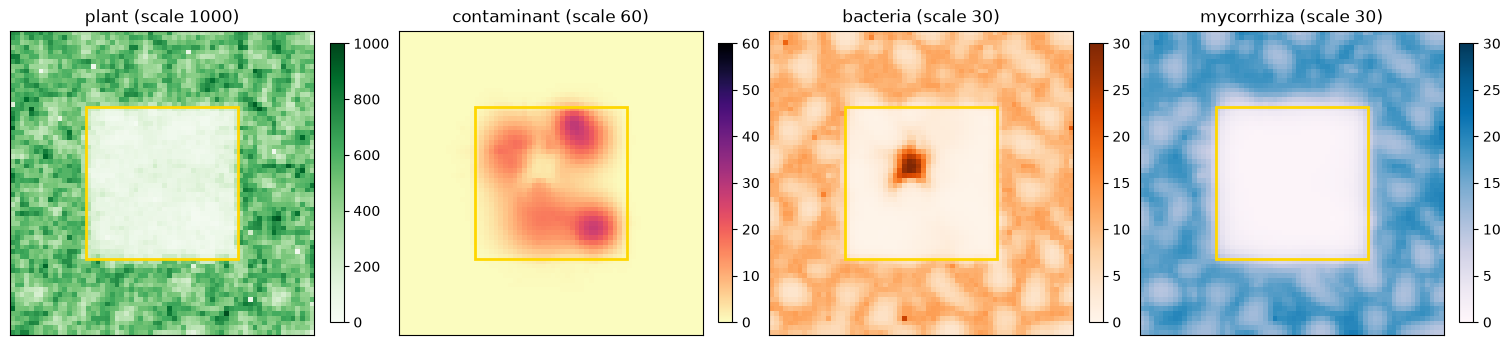

In [10]:
frame = greedy.frame()
print(f"{frame['date']} | frame is {len(json.dumps(frame)) / 1024:.0f} KB of JSON | "
      f"{len(frame['fields'])} fields | {len(frame['flows'])} recent network flows")
def decode(name):
    raw = np.frombuffer(base64.b64decode(frame["fields"][name]), dtype=np.uint8)
    return raw.reshape(frame["grid"]) / 255 * frame["scales"][name]

fig, axes = plt.subplots(1, 4, figsize=(15, 3.8), constrained_layout=True)
for ax, (name, cmap) in zip(axes, [("plant", "Greens"), ("contaminant", "magma_r"),
                                   ("bacteria", "Oranges"), ("mycorrhiza", "PuBu")]):
    field_map(ax, decode(name), f"{name} (scale {FIELD_SCALES[name]:g})", cmap, FIELD_SCALES[name])

The surface view draws ground colour from moisture, litter and contamination, a plant sprite per cell and wandering insects. The underground view draws soil, bacteria, the contaminant plume, a pruned hyphal network that glows with fungal carbon, and nutrient pulses travelling along the keystone agent's shuttles (`flows`). Layers that only change when a frame arrives are cached as textures, so per-frame JavaScript is about 0.1 ms.

## 8. The WebSocket protocol

The server (`server/app.py`) holds one session. A client connects to `/ws`, gets a `hello` (sim version, speeds, tool list) and a first frame, then sends commands. Every command gets an `ack` or an `error` with a reason. `TestClient` runs the real app in-process.

In [11]:
def reply(ws):
    while (msg := ws.receive_json())["type"] == "frame":  # frames are broadcast between replies
        pass
    return msg

with TestClient(create_app(ServerConfig(seed=1))) as client:
    print("health:", client.get("/api/health").json())
    with client.websocket_connect("/ws") as ws:
        hello, first = ws.receive_json(), ws.receive_json()
        print("hello: speeds", hello["speeds"], "|", len(hello["tools"]), "tools | first frame tick", first["tick"])
        for cmd in ({"cmd": "step", "days": 2},
                    {"cmd": "tool", "tool": "seed", "x": 20, "y": 20},
                    {"cmd": "tool", "tool": "spill", "x": 20, "y": 20},
                    {"cmd": "whisper", "text": "   "},
                    {"cmd": "speed", "value": 7},
                    {"cmd": "step", "days": 1}):
            ws.send_json(cmd)
            print(f"{json.dumps(cmd):>52} -> {reply(ws)}")
    record = client.get("/api/record").json()
print("record:", record["ticks"], "ticks,", len(record["intents"]), "intents:",
      sorted({i["kind"] for i in record["intents"]}))

health: {'ok': True, 'sim_version': '0.2.0', 'tick': 0}
hello: speeds [0, 6, 24, 96, 336] | 9 tools | first frame tick 0
                          {"cmd": "step", "days": 2} -> {'type': 'ack', 'cmd': 'step'}
   {"cmd": "tool", "tool": "seed", "x": 20, "y": 20} -> {'type': 'ack', 'cmd': 'tool'}
  {"cmd": "tool", "tool": "spill", "x": 20, "y": 20} -> {'type': 'error', 'cmd': 'tool', 'error': 'Spill is only available in research mode'}
                   {"cmd": "whisper", "text": "   "} -> {'type': 'error', 'cmd': 'whisper', 'error': 'empty whisper'}
                        {"cmd": "speed", "value": 7} -> {'type': 'error', 'error': 'speed must be one of (0, 6, 24, 96, 336)'}


                          {"cmd": "step", "days": 1} -> {'type': 'ack', 'cmd': 'step'}
record: 72 ticks, 9 intents: ['excavate', 'seed', 'spill']


## 9. Replay: the whole game, without the game

The session's record is a Phase 0 replay record: seed, sim version, params, and every accepted intent with its tick. That now includes the scenario's setup, the player's tools, the director's events and the agent's actions. Replaying it runs the sim alone: no session, no director, no players, and (booby-trapped here) no model.

In [12]:
record = greedy.record()
by_agent = {}
for i in record.intents:
    by_agent.setdefault(i.agent, []).append(i.kind)
for agent, kinds in by_agent.items():
    print(f"{agent:>9}: {len(kinds):>3} intents  {dict(sorted({k: kinds.count(k) for k in kinds}.items()))}")

def forbidden(*a, **k):
    raise AssertionError("a model was called during replay")
original, Router.complete = Router.complete, forbidden
try:
    t0 = time.perf_counter()
    again = replay(record)
finally:
    Router.complete = original
print(f"\nreplayed {record.ticks} ticks in {time.perf_counter() - t0:.0f} s; "
      f"bit-identical: {again.state_hash() == record.final_hash}")

 scenario:   8 intents  {'excavate': 4, 'spill': 4}
     user:  27 intents  {'amend': 10, 'inoculate': 9, 'seed': 8}
 mycelium:  21 intents  {'set_trade_bias': 11, 'shuttle_nutrients': 10}
 director:   1 intents  {'spill': 1}



replayed 4320 ticks in 11 s; bit-identical: True


## Gate B

| Half | Status |
|---|---|
| Brownfield playable end to end | **Passes in CI** (`test_brownfield_is_winnable_by_a_sensible_player`, about 3 minutes). A scripted greedy gardener wins before the deadline (on day 1024 of 1095 when it was balanced, seed 42); an idle one loses. |
| 60 fps with ~2,000 entities | **Not verified.** The sandbox has no GPU. In headless Chromium on SwiftShader, a CPU software rasterizer, `/?bench` reaches 35–43 fps at 800×450 with 4,700–9,700 entities, and per-frame JS work is about 0.1 ms. At 1600×900 the software fill rate drops it to single digits. |

The bench numbers say the bottleneck is fill rate, not the game code, which is what a GPU fixes. But that's an argument, not a measurement.

## What broke (and what got fixed)

1. **The client deadlocked in every browser.** `await app.init()` at module level: Pixi's `init()` dynamically imports a chunk that imports the main module back. Startup now runs inside an async function. WebGL is the default renderer, because WebGPU init stalled on some drivers.
2. **Inocula never spread.** Phase 1 left microbes static, so fungi only moved when the keystone agent relocated them, and a dose of bacteria stayed exactly where it was dropped. Each guild now disperses slowly (fungi 0.08/day, bacteria 0.02/day), and Gate A still holds.
3. **Compost and excavation broke the carbon check.** The closed-carbon budget assumed carbon only crosses the boundary via the air. Compost brought in and soil hauled away now book their carbon as external imports and exports.
4. **The scenario setup tripped the pacing rules.** Four excavations and four spills at tick 0 exceeded the per-tick rate limit for any non-player agent. Setup now comes from a `scenario` agent that, like the player, is exempt from pacing limits.
5. **Balancing took iteration.** The default contaminant is PAH-like and slow to degrade, so microbes, and the player's help, made little headway in three years. Brownfield uses a far more biodegradable diesel-range contaminant instead (`degradation_per_day=0.035`), and all of its contamination comes from the site spills rather than random hotspots. The scripted players were the balancing tool: greedy now wins with about two months to spare, and idle loses.
6. **Software rendering hid the fps answer.** The sandbox's only renderer is SwiftShader, so `/?bench` reports JS timings separately from fps. That at least shows the per-frame code isn't the problem.

## Known issues

- **The 60 fps half of Gate B is unverified on a real GPU.** Open `/?bench` (try `&view=underground`, `&aa=0`, `&regen=0`) on a machine with one.
- **Agents have only run on the scripted stand-in.** The off-thread path is tested with a slowed scripted policy (section 6), not with a real model's latency or its JSON reliability. Whether a 7B model weighs a whisper sensibly is untested.
- **The director's schedule ignores natural recovery,** so it can punish a player who is "ahead" only because the meadow regrew on its own (section 4).
- **The greedy player is the only evidence the scenario is fair.** It's a heuristic; no human has played it to the end.
- **One session per server.** All browsers share it; `new_game` resets it for everyone.
- **A skipped decision is silent to the player.** If the narrator is still writing when the network is due, that week's decision is skipped and only the log says so.

## Try it

```bash
cd client && pnpm install && pnpm build && cd ..
uv run python -m server                    # http://localhost:8000; /?bench for fps
```

1. Whisper the name of a well-fed patch, then a hungry one, and compare the inspector's deliberation.
2. Write a player that only uses bacteria and compost. How far does it get, and why does the network objective stall?
3. Switch to research mode, spill next to a fungal hub and watch the network pull its hyphae away in the underground view.